# **Modelos de clasificación**

Aplicación de modelos de aprendizaje de maquina para la confirmación de casos de Dengue en Colombia.

## **Datos**

De los datos extraidos de SIVIGILA se cuenta con $947280$ observaciones de casos registrados de Dengue en Colombia.

📄Lectura del archivo de datos\
📍Selección de variables de estudio

In [1]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Lectura de datos
data = pd.read_csv(r"C:\Users\Hp\MACHINE\Base_dengue.csv",dtype={11:str, 36: str}, low_memory=False)

data['SEXO_NUM'] = data['SEXO'].astype(str).str.strip().map({'F': 0, 'M': 1})
data['SEXO_NUM'] = data['SEXO_NUM'].fillna(-1).astype('int64')

In [3]:
#Seleccion de variables de estudio"
columnas = [ "EDAD_AJUSTADA", "SEXO_NUM", "TIP_SS", 
            "GP_MIGRANT", "GP_POBICFB", "GP_GESTAN", 
            "AREA", "PAIS_OCU", "DPTO_OCU", "MUN_OCU",
            "SEMANA", "ANO", 
            "EVENTO", "TIP_CAS", 
            "PAC_HOS", "CON_FIN", 
            "confirmados",
           ]
df = data[columnas]

# Ajuste de edades menores a un año (Representación de en días, semanas o meses, variable que representa años)
df.loc[df["EDAD_AJUSTADA"] < 1, "EDAD_AJUSTADA"] = 1 

# Reemplazo de NA en la variable EDAD_AJUSTADA por la mediana de la variable
mediana_eda = df['EDAD_AJUSTADA'].median()
df.loc[:, 'EDAD_AJUSTADA'] = df['EDAD_AJUSTADA'].fillna(mediana_eda)

# ajuste de tipos de datos
df.loc[:,'EDAD_AJUSTADA'] = df['EDAD_AJUSTADA'].astype('int64')

print("Variables de estudio:")
print(df.info())

Variables de estudio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947280 entries, 0 to 947279
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   EDAD_AJUSTADA  947280 non-null  float64
 1   SEXO_NUM       947280 non-null  int64  
 2   TIP_SS         947280 non-null  object 
 3   GP_MIGRANT     947280 non-null  int64  
 4   GP_POBICFB     947280 non-null  int64  
 5   GP_GESTAN      947280 non-null  int64  
 6   AREA           947280 non-null  int64  
 7   PAIS_OCU       947280 non-null  object 
 8   DPTO_OCU       947280 non-null  object 
 9   MUN_OCU        947280 non-null  object 
 10  SEMANA         947280 non-null  int64  
 11  ANO            947280 non-null  int64  
 12  EVENTO         947280 non-null  object 
 13  TIP_CAS        947280 non-null  int64  
 14  PAC_HOS        947280 non-null  int64  
 15  CON_FIN        947280 non-null  int64  
 16  confirmados    947280 non-null  int64  
dtypes: floa

## **Modelos**

Ejecución y evaluación de modelos de clasificación para la variable respuesta *'confirmados'*. \
Se desea predecir si un caso de dengue será catalogado como confirmado o no.

|Evento| Clase|
|------|-------|
| Casos positios | 1|
|Casos negativos |0|

📌 Entrenamiento y comparación de los siguientes modelos:

1️⃣ K-Nearest Neighbors (KNN) \
2️⃣ Naive Bayes \
3️⃣ Regresión Logística (con L1(Ridge) y L2(Lasso))\
4️⃣ Árbol de Decisión\
5️⃣ Random Forest\
6️⃣ XGBoost\
7️⃣ Support Vector Machine (SVM)


---

### **Fase 1:**
📁 Procesamiento de los datos

#### Balanceo:

In [4]:
# Verificación de desbalance de la clase 'confirmados'
contar_conf = df['confirmados'].value_counts()
porcentaje_conf = df['confirmados'].value_counts(normalize=True) * 100

print("Porcentaje de la variable 'confirmados'")  
balance = pd.DataFrame({
    "Clase": contar_conf.index,
    "Frecuencia": contar_conf.values,
    "Porcentaje (%)": porcentaje_conf.values
})
balance

Porcentaje de la variable 'confirmados'


,Clase,Frecuencia,Porcentaje (%)
0,1,543564,57.381556
1,0,403716,42.618444


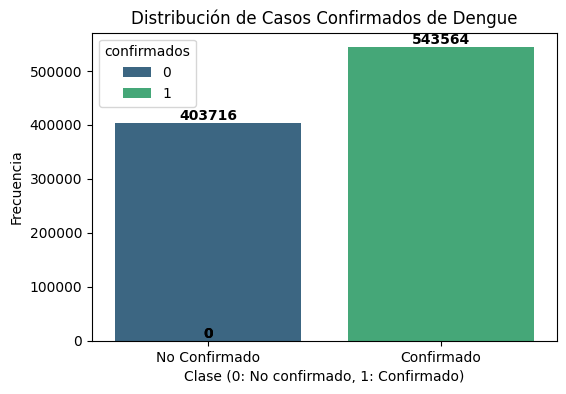

In [7]:
# Gráfica de la variable 'confirmados'
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=contar_conf.index, y=contar_conf.values, hue = contar_conf.index , palette="viridis")
# Agregar valores encima de las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.xlabel("Clase (0: No confirmado, 1: Confirmado)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Casos Confirmados de Dengue")
plt.xticks(ticks=[0, 1], labels=["No Confirmado", "Confirmado"])
plt.show()

La variable respuesta no esta desbalanceada $(54.48\% \ vs. \ 42.62\%)$. Se considera no necesario aplicar tecnicas de balanceo.

#### Codificación de variables categoricas
| Variable | Tipo de dato | Método|
|------|------|-----|
| Sexo | Binaria| Label |
| Tipo de seguridad social| Categorias (pocas)| One-Hot|
| Pais, departamento, municipio ocurrencia| Muchas categorias| Target|
| Evento | Categoricas (pocas) | One-Hot|



In [5]:
# Tipo aseguradora y Evento (One-Hot Encoding)
df = pd.get_dummies(df, columns=['TIP_SS', 'EVENTO'], drop_first=True)

# Pais, municipio y departamento (Frecuencias)
for col in ['PAIS_OCU', 'DPTO_OCU', 'MUN_OCU']:
    freq = df[col].value_counts(normalize=True).to_dict()
    df[col] = df[col].map(freq).fillna(0).astype('float64')

#### Escalado de la variable edad

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Escalado de variables numéricas
df['EDAD_AJUSTADA'] = scaler.fit_transform(df[['EDAD_AJUSTADA']])

#### Matriz de correlación

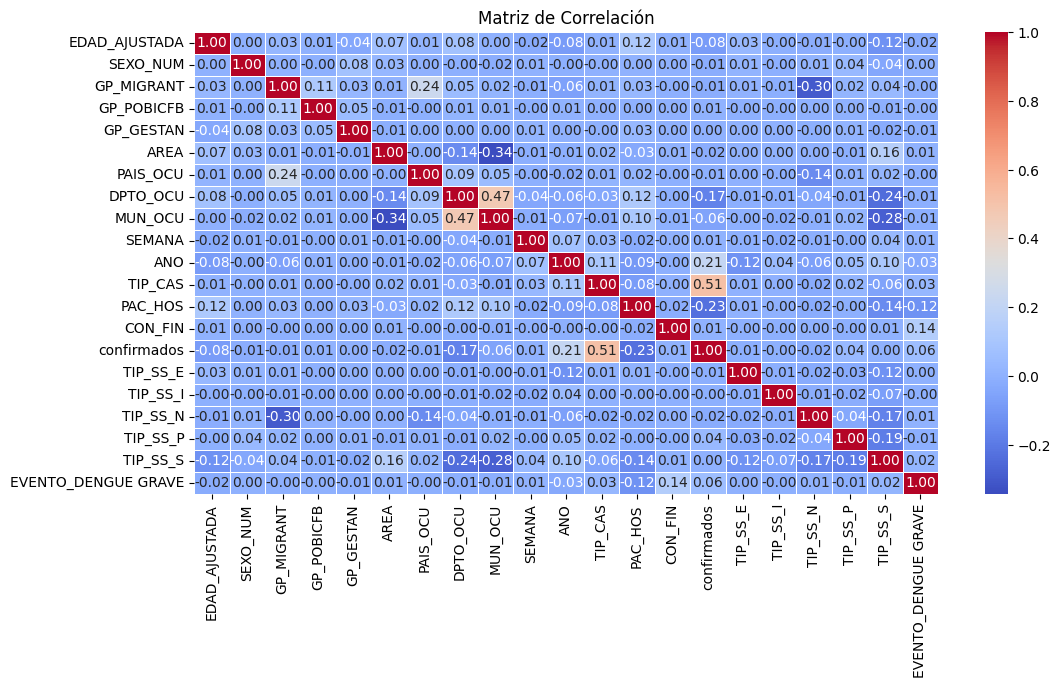

In [10]:
# Matriz de correlación con metodo Spearman
corr_matric = df.corr(method='spearman')

# Visualizar con un heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matric, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

Las correlaciones más altas se tienen para:
- *TIP_CAS* - *confirmados* (0.51) moderada, relación esperable considerando el caso inicial y el final
- *MUN_OCU* - *DPTO_OCU* (0.47), los municipios de un departamento

---

### **Fase 2:**
📌 Selección de modelos y evaluación Inicial \
Métricas de clasificación para comparar modelos en la fase inicial:

✅ Accuracy (Precision)\
✅ Recall (Sensibilidad)\
✅ Precisión (Precision)\
✅ F1-Score\
✅ROC-AUC


In [17]:
# Librerias de modelado

# Procesamiento de datos
from sklearn.preprocessing import StandardScaler

# Division de datos
from sklearn.model_selection import train_test_split

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier

# Evaluación de modelos
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
# Ajuste de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Otras tecnicas
from sklearn.kernel_approximation import RBFSampler

In [8]:
# División de conjuntos de datos

# Definir variable predictora y objetivo
X = df.drop(columns=['confirmados'])
y = df['confirmados'] 

# Division en train y test (60% train, 20% test, 20% validación)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

# Verificación de la división
print(f"Train: {X_train.shape}, Test: {X_test.shape}, Validation: {X_val.shape}")
print(f"Train: {y_train.shape}, Test: {y_test.shape}, Validation: {y_val.shape}")

#Escalado de variables
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Train: (568368, 20), Test: (189456, 20), Validation: (189456, 20)
Train: (568368,), Test: (189456,), Validation: (189456,)


In [9]:
# Uso de nucleo de 8 cores para el procesamiento paralelo
# Configuración de multiprocessing para usar 8 núcleos
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8" 
import time

#### 📍 KNN y Bayes

In [14]:
# Modelos a evaluar
models_KB = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

In [15]:
# Entrenar y evaluar
for name, model in models_KB.items():
    print(f"\n🔹 Modelo: {name}")
    
    # Para KNN usamos los datos escalados, para Naive Bayes los originales
    X_train_model = X_train_scaled if "KNN" in name else X_train
    X_val_model = X_val_scaled if "KNN" in name else X_val

    start_time = time.time()

    model.fit(X_train_model, y_train)  # Entrenar el modelo
    y_pred = model.predict(X_val_model)  # Predicción
    y_proba = model.predict_proba(X_val_model)[:, 1]  # Probabilidades

    end_time = time.time()

    # Reporte de clasificación
    print(classification_report(y_val, y_pred))
    
    # Métrica ROC-AUC
    roc_auc = roc_auc_score(y_val, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Tiempo de entrenamiento
    elapsed_time = end_time - start_time
    print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")

    


🔹 Modelo: KNN (k=5)
              precision    recall  f1-score   support

           0       0.73      0.77      0.75     80743
           1       0.82      0.79      0.81    108713

    accuracy                           0.78    189456
   macro avg       0.78      0.78      0.78    189456
weighted avg       0.78      0.78      0.78    189456

ROC-AUC: 0.8588
Tiempo de entrenamiento: 261.95 segundos

🔹 Modelo: Naive Bayes
              precision    recall  f1-score   support

           0       0.58      0.99      0.73     80743
           1       0.98      0.48      0.64    108713

    accuracy                           0.69    189456
   macro avg       0.78      0.73      0.69    189456
weighted avg       0.81      0.69      0.68    189456

ROC-AUC: 0.8347
Tiempo de entrenamiento: 0.54 segundos


Evaluación inicial **KNN** y **Naive Bayes**:

- KKN (k=5):
Tiene mejor rendimiento general, la clase 1 tiene mejor precisión y f1-score, identifica mejor los casos confirmados. La metrica ROC-AUC 0.85 indica que el modelo discrimina bien entre clases.

- Naive Bayes:
Clasifica bien los casos no confirmados (recall 99%), pero falla en identificar los confirmados. Predice pocos casos como confirmados. El valor F1 (0.64) indica que el modelo no logra capturar bien los positivos. 

En general, es mejor el modelo KNN. El modelo Bayes tiene problema para clasificar los casos confirmados

Para mejorar KNN, se podria modificar los valores para k.

#### 📍Regresión logística

In [16]:
# Lista de modelos a evaluar
models_RG = {
    "Logistic Regression (L1 - Lasso)": LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
    "Logistic Regression (L2 - Ridge)": LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000),
}

In [17]:
# Entrenar y evaluar
for name, model in models_RG.items():
    print(f"\n🔹 Modelo: {name}")
    
    start_time = time.time()  # Iniciar temporizador

    model.fit(X_train_scaled, y_train)  # Entrenar
    y_pred = model.predict(X_val_scaled)  # Predicción
    y_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probabilidades
    
    end_time = time.time()  # Finalizar temporizador

    # Reporte de clasificación
    print(classification_report(y_val, y_pred))
    
    # Métrica ROC-AUC
    roc_auc = roc_auc_score(y_val, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Tiempo de entrenamiento
    elapsed_time = end_time - start_time
    print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")


🔹 Modelo: Logistic Regression (L1 - Lasso)
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     80743
           1       0.82      0.75      0.79    108713

    accuracy                           0.77    189456
   macro avg       0.76      0.77      0.76    189456
weighted avg       0.77      0.77      0.77    189456

ROC-AUC: 0.8554
Tiempo de entrenamiento: 53.00 segundos

🔹 Modelo: Logistic Regression (L2 - Ridge)
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     80743
           1       0.82      0.75      0.79    108713

    accuracy                           0.77    189456
   macro avg       0.76      0.77      0.76    189456
weighted avg       0.77      0.77      0.77    189456

ROC-AUC: 0.8554
Tiempo de entrenamiento: 0.63 segundos


Evaluación inicial **Regresión**:

Para los casos de Lasso(L1) y Ridge(L2) se obtuvieron las mismas métricas, lo que sugiere que la regularización no tuvo gran impacto en el rendimiento final.

Ambos modelos estan balanceados en términos de precisión y recuperación. El modelo discrimina bien las clases.

Para mejorar el modelo: Seleccionar mejores hiperparámetros y eliminar caracteristicas irrelevantes.

#### 📍 Árboles

In [18]:
# Lista de modelos a evaluar
models_A = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss",random_state=42),
}

In [19]:
# Entrenar y evaluar cada modelo
for name, model in models_A.items():
    print(f"\n🔹 Modelo: {name}")

    # Iniciar temporizador
    start_time = time.time()

    model.fit(X_train, y_train)  # Entrenar
    y_pred = model.predict(X_val)  # Predecir en validación
    y_proba = model.predict_proba(X_val)[:, 1]  # Probabilidades para ROC-AUC
    
    end_time = time.time()  # Finalizar temporizador

    # Reporte de clasificación	
    print(classification_report(y_val, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")

    # Tiempo de entrenamiento
    train_time = end_time - start_time
    print(f"Tiempo de entrenamiento: {train_time:.4f} segundos")
    


🔹 Modelo: Decision Tree
              precision    recall  f1-score   support

           0       0.76      0.76      0.76     80743
           1       0.82      0.82      0.82    108713

    accuracy                           0.80    189456
   macro avg       0.79      0.79      0.79    189456
weighted avg       0.80      0.80      0.80    189456

ROC-AUC: 0.7947
Tiempo de entrenamiento: 3.2020 segundos

🔹 Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.78      0.83      0.81     80743
           1       0.87      0.83      0.85    108713

    accuracy                           0.83    189456
   macro avg       0.82      0.83      0.83    189456
weighted avg       0.83      0.83      0.83    189456

ROC-AUC: 0.9102
Tiempo de entrenamiento: 94.0422 segundos

🔹 Modelo: XGBoost
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     80743
           1       0.89      0.82      0.85    108713

Evaluación inicial **Árboles**:

- Decisión Tree:
Los valores de recall y precision son similares, lo cual indica que el modelo no tiene sesgo fuerte hacia una clase.Aunque el valor de AUC es bajo.

- Random Forest:
Tiene mucho mejor rendimiento que un árbol simple. Las metricas son mas equilibradas, lo que indica que el modelo generaliza mejor. El ROC-AUC es más robusto para clasificar correctamente ambas clases.

- XGBoost:
Es el mejor modelo hasta ahora, con la mejor combinación de precision y recall. El valor ROC_AUC de 0.92, lo que indica que discrimina mejor entre clases.

Se pueden mejorar los hiperpárametros en Random Forest y XGBoost.

#### 📍SVM

In [20]:
# Modelo SVM con calibración de probabilidad
svm = SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3, random_state=42)
svm_calibrado = CalibratedClassifierCV(svm, method='sigmoid', cv=5)  # Calibración con validación cruzada

In [21]:
# Entrenar
start_time = time.time()  # Iniciar temporizador

svm_calibrado.fit(X_train_scaled, y_train)  
y_pred = svm_calibrado.predict(X_val_scaled)
y_proba = svm_calibrado.predict_proba(X_val_scaled)[:, 1]  

end_time = time.time()  # Finalizar temporizador

# Reporte de clasificación
print("\n🔹 Modelo: SVM Lineal (Calibrado)")
print(classification_report(y_val, y_pred))

# Métrica ROC-AUC
roc_auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

# Tiempo de entrenamiento
elapsed_time = end_time - start_time
print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")


🔹 Modelo: SVM Lineal (Calibrado)
              precision    recall  f1-score   support

           0       0.70      0.77      0.73     80743
           1       0.82      0.76      0.79    108713

    accuracy                           0.76    189456
   macro avg       0.76      0.76      0.76    189456
weighted avg       0.77      0.76      0.76    189456

ROC-AUC: 0.8533
Tiempo de entrenamiento: 8.60 segundos


Evaluación inicial **SVM**

El modelo tiene un buen desempeño en clasificación, el valor de F1 está balanceado. Aunque clasifica mejor la clase positivos.

----

### **Fase 3:**
☑️Optimización de modelos \
☑️Ajuste de hiperparámetros

In [10]:
# Función para graficar la curva ROC
def plot_roc_curve(y_test, y_proba, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {model_name}")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

#### 📍KNN y Naive Bayes
KNN:\
☑️FAISS

Bayes: \
☑️Partial Fit

In [23]:
# FAISS
import faiss

# Crear el índice FAISS
index = faiss.IndexFlatL2(X_train_scaled.shape[1])  
index.add(np.ascontiguousarray(X_train_scaled))  


🔹 Modelo: FAISS KNN (k=3)
              precision    recall  f1-score   support

           0       0.73      0.75      0.74     80743
           1       0.81      0.79      0.80    108713

    accuracy                           0.77    189456
   macro avg       0.77      0.77      0.77    189456
weighted avg       0.78      0.77      0.77    189456

ROC-AUC: 0.8376
Tiempo de entrenamiento: 90.6908 segundos


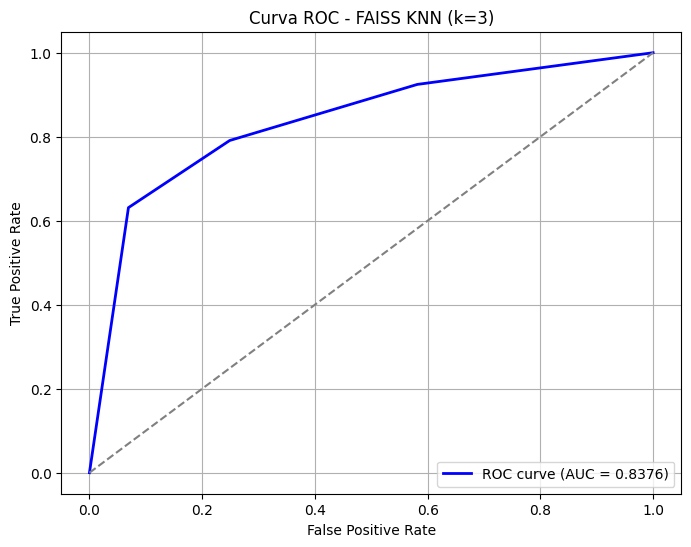

In [24]:
# Medir tiempo de entrenamiento
start_train = time.time()
D, I = index.search(np.ascontiguousarray(X_val_scaled), 3)  # Búsqueda de los 3 vecinos más cercanos
search_time = time.time() - start_train

# Aseguramos que y_train sea un array NumPy para evitar problemas con Pandas
y_train_np = np.array(y_train)  

# Seleccionar etiquetas de los vecinos más cercanos
y_neighbors = y_train_np[I]  # Ahora y_neighbors tendrá dimensión (189456, 5)

# Calcular probabilidades (promedio de la clase de los vecinos)
y_proba = np.mean(y_neighbors, axis=1)  # Reducimos dimensión a (189456,)
y_pred = (y_proba >= 0.5).astype(int)  # Predicción binaria
# Reporte de clasificación
print("\n🔹 Modelo: FAISS KNN (k=3)")
print(classification_report(y_val, y_pred))

# Métrica ROC-AUC
roc_auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

# Tiempo de cómputo
print(f"Tiempo de entrenamiento: {search_time:.4f} segundos")

# Graficar la curva ROC para FAISS
plot_roc_curve(y_val, y_proba, "FAISS KNN (k=3)")

La optimización con **FAISS** permitió una reducción significativa en el tiempo de ejecución sin afectar drásticamente el rendimiento del modelo. Aunque las métricas presentan una ligera disminución en comparación con la implementación inicial, el comportamiento se mantiene estable. El modelo optimizado sigue mostrando una mayor capacidad para clasificar la Clase 1. En cuanto a la curva ROC, el área bajo la curva ROC-AUC, disminuyó un poco, aunque no deja de tener una moderada capacidad para clasificar correctamente, el comportamiento en los primeros segmentos de la curva indica que el modelo logra una alta tasa de verdaderos positivos con una baja tasa de falsos positivos, lo cual es una característica deseable, note que la gráfica tiene comportamiento por segmentos.

In [25]:
# Modelo Naive Bayes con partial_fit
nb_model = GaussianNB()


🔹 Modelo: Naive Bayes (Partial Fit)
              precision    recall  f1-score   support

           0       0.58      0.99      0.73     80743
           1       0.98      0.48      0.64    108713

    accuracy                           0.69    189456
   macro avg       0.78      0.73      0.69    189456
weighted avg       0.81      0.69      0.68    189456

ROC-AUC: 0.8347
Tiempo de entrenamiento: 0.5191 segundos


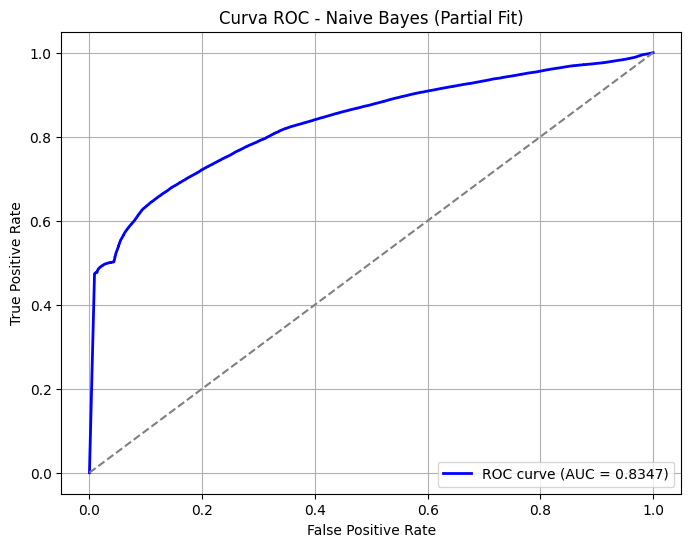

In [26]:
# Entrenamiento por lotes
start_time = time.time()  # Tiempo inicial entrenamiento

nb_model.partial_fit(X_train_scaled, y_train, classes=[0, 1])
y_pred = nb_model.predict(X_val_scaled)
y_proba = nb_model.predict_proba(X_val_scaled)[:, 1]
end_time = time.time()  # Tiempo final entrenamiento

train_time = end_time - start_time

# Reporte de clasificación
print("\n🔹 Modelo: Naive Bayes (Partial Fit)")
print(classification_report(y_val, y_pred))

# Métrica ROC-AUC
roc_auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

# Tiempo de cómputo
print(f"Tiempo de entrenamiento: {train_time:.4f} segundos")

# Graficar la curva ROC para Naive Bayes
plot_roc_curve(y_val, y_proba, "Naive Bayes (Partial Fit)")

El tiempo de ejecución fue significativamente reducido. Sin embargo, en términos de rendimiento, las métricas muestran un fuerte des balance entre clases, como en la ejecución inicial. El área bajo la curva, indica que el modelo tiene un buen desempeño en la capacidad de discriminación entre clases, en el gráfico se observa una curva que no alcanza una alta tasa de verdaderos positivos con pocos falsos positivos.

#### 📍Regresión Logística
☑️ Solver "saga"

In [27]:
# Modelos de regresión logística con SAGA
models_RG_saga= {
    "Logistic Regression (L1 - Lasso, SAGA)": LogisticRegression(penalty="l1", solver="saga", max_iter=1000),
    "Logistic Regression (L2 - Ridge, SAGA)": LogisticRegression(penalty="l2", solver="saga", max_iter=1000),
}


🔹 Modelo: Logistic Regression (L1 - Lasso, SAGA)
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     80743
           1       0.82      0.75      0.79    108713

    accuracy                           0.77    189456
   macro avg       0.76      0.77      0.76    189456
weighted avg       0.77      0.77      0.77    189456

ROC-AUC: 0.8554
Tiempo de entrenamiento: 277.73 segundos


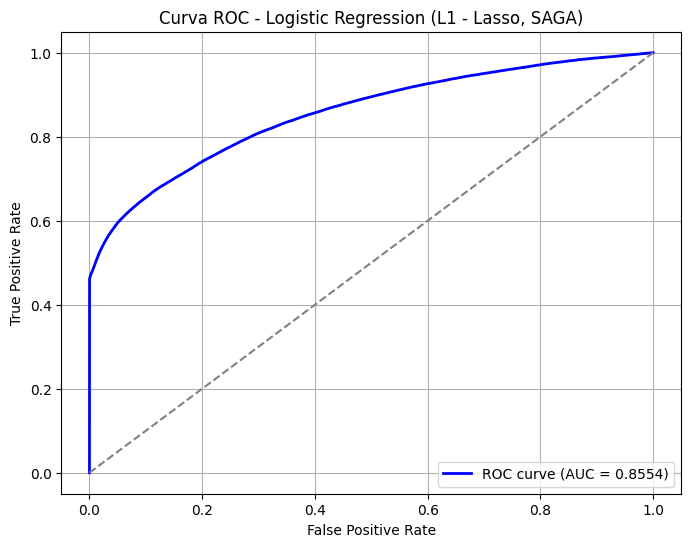


🔹 Importancia de características:
       Feature  Importance
11  Feature 11    6.229548
7    Feature 7    0.574051
10  Feature 10    0.488613
12  Feature 12    0.474601
0    Feature 0    0.154721


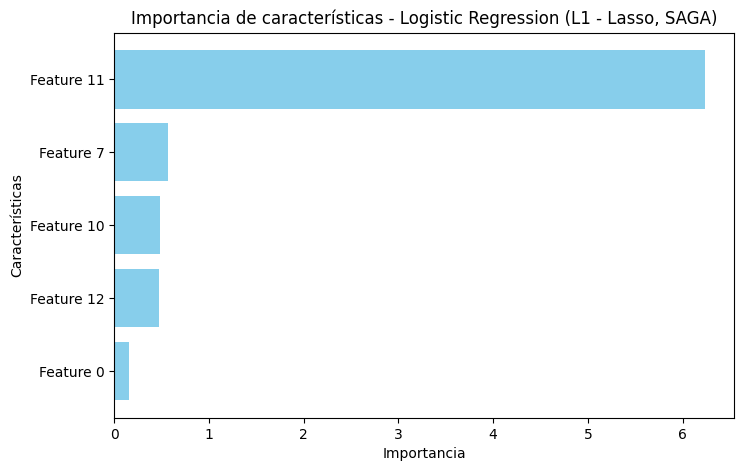




🔹 Modelo: Logistic Regression (L2 - Ridge, SAGA)
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     80743
           1       0.82      0.75      0.79    108713

    accuracy                           0.77    189456
   macro avg       0.76      0.77      0.76    189456
weighted avg       0.77      0.77      0.77    189456

ROC-AUC: 0.8554
Tiempo de entrenamiento: 136.77 segundos


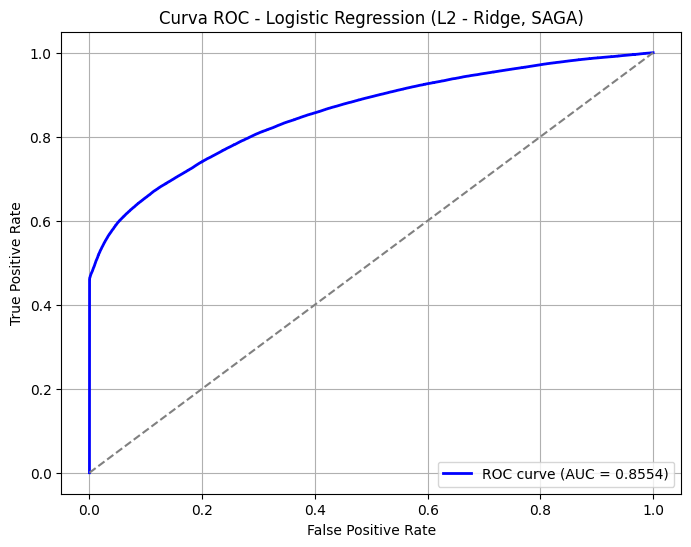


🔹 Importancia de características:
       Feature  Importance
11  Feature 11    5.709907
7    Feature 7    0.574053
10  Feature 10    0.488611
12  Feature 12    0.474602
0    Feature 0    0.154725


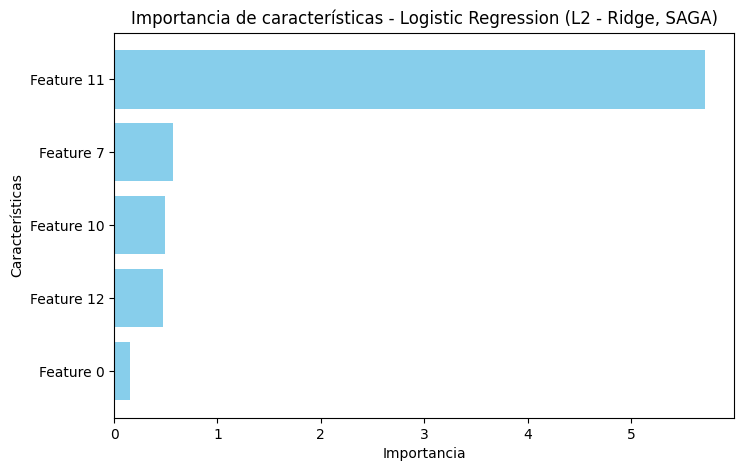

In [28]:
# Entrenar y evaluar
for name, model in models_RG_saga.items():
    print(f"\n🔹 Modelo: {name}")
    
    start_time = time.time()  # Iniciar temporizador
    model.fit(X_train_scaled, y_train)  # Entrenar
    y_pred = model.predict(X_val_scaled)  # Predicción
    y_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probabilidades
    end_time = time.time()  # Finalizar temporizador

    # Reporte de clasificación
    print(classification_report(y_val, y_pred))
    
    # Métrica ROC-AUC
    roc_auc = roc_auc_score(y_val, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Tiempo de entrenamiento
    elapsed_time = end_time - start_time
    print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")

    # Gráfica de la curva ROC para los modelos de regresión logística
    plot_roc_curve(y_val, y_proba, name)
    
    # Importancia de características
    feature_importance = np.abs(model.coef_).flatten()  # Tomar el valor absoluto de los coeficientes
    feature_names = X_train_scaled.columns if hasattr(X_train_scaled, "columns") else [f"Feature {i}" for i in range(X_train_scaled.shape[1])]

    # Crear un DataFrame con la importancia de características
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importance})
    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    print("\n🔹 Importancia de características:")
    print(importance_df.head(5))  # Mostrar las 10 más importantes

    # Gráfico de barras de las características más importantes
    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["Feature"][:5], importance_df["Importance"][:5], color="skyblue")
    plt.xlabel("Importancia")
    plt.ylabel("Características")
    plt.title(f"Importancia de características - {name}")
    plt.gca().invert_yaxis()  # Invertir para que la más importante esté arriba
    plt.show()

    print("\n" + "="*50 + "\n")  # Separador entre modelos


Los resultados muestran que si bien las métricas de clasificación se mantienen estables, el tiempo de ejecución aumenta significativamente con 'saga'. La regularización $L_1$ presentó un tiempo de ejecución casi el doble de $L_2$. A pesar del mayor costo computacional, el rendimiento del modelo en términos de discriminación de clases (ROC-AUC) no experimento mejoras sustanciales. La curva dibujada, comienza su inclinación luego de una tasa de falsos positivos de 0.4, 

En cuanto a la importancia de variables, para $L_1$ la variable 'Año' fue la más influyente en la clasificación con un valor de $6.2$, seguida de las variables 'País de ocurrencia', 'Semana' y 'Evento', con valores entre $0.47$ y $0.57$. En el caso de $L_2$, la importancia de la variable 'Año' se redujo a $0.570$. Esto sugiere la regularización $L_1$ favorece una selección más estricta de características relevantes. 

#### 📍Árboles (Random Forest, XGBoost)
☑️ Random Forest: GridSearch para mejores parámetros

☑️ XGBoost: Método _"hist"_


In [29]:
# Definir el modelo base
rf = RandomForestClassifier(random_state=42)

# Definir el grid de hiperparámetros
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

In [30]:
# Grid Search con validación cruzada
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros
print("Mejores parámetros:", grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


In [12]:
# Modelo optimizado con los mejores hiperparámetros
rf_optimized = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None, 
    min_samples_split=10, 
    random_state=42
)


🔹 Modelo: Random Forest (Optimizado)
              precision    recall  f1-score   support

           0       0.78      0.85      0.82     80743
           1       0.88      0.82      0.85    108713

    accuracy                           0.84    189456
   macro avg       0.83      0.84      0.84    189456
weighted avg       0.84      0.84      0.84    189456

ROC-AUC: 0.9187
Tiempo de entrenamiento: 132.2077 segundos


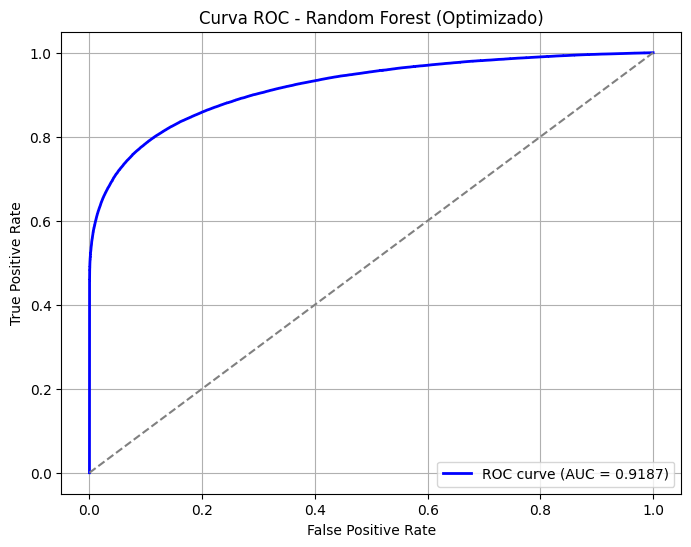

In [16]:
# Medir tiempo de entrenamiento
start_time = time.time()
rf_optimized.fit(X_train, y_train)

# Predicciones
y_pred = rf_optimized.predict(X_test)
y_proba = rf_optimized.predict_proba(X_test)[:, 1]  # Probabilidades para AUC-ROC

train_time = time.time() - start_time

# Evaluación
print("\n🔹 Modelo: Random Forest (Optimizado)")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Tiempo de entrenamiento: {train_time:.4f} segundos")

# Graficar la curva ROC para el modelo optimizado
plot_roc_curve(y_test, y_proba, "Random Forest (Optimizado)")

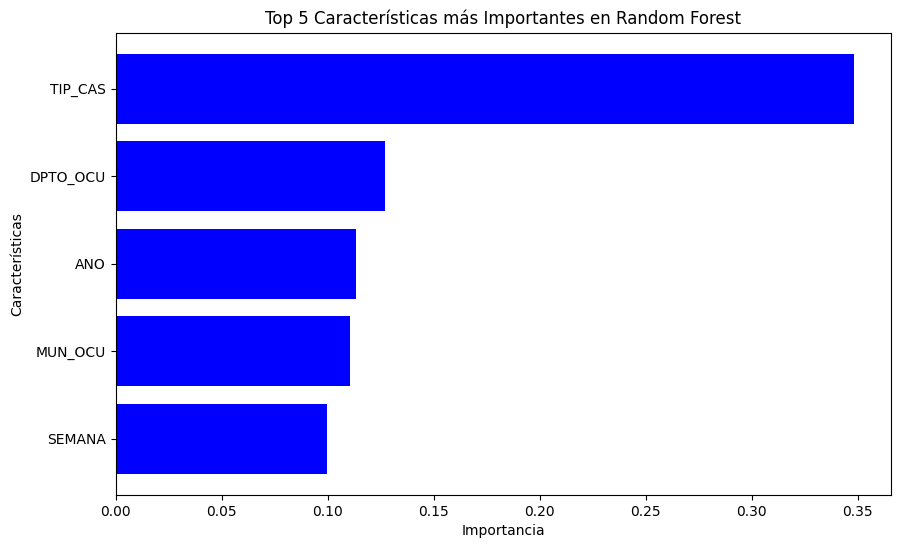

In [33]:
# Obtener importancia de características
feature_importance = rf_optimized.feature_importances_

# Ordenar las características por importancia
indices = np.argsort(feature_importance)[::-1]
features_sorted = [X_train.columns[i] for i in indices]
importances_sorted = feature_importance[indices]

# Seleccionar las 5 características más importantes
top_n = 5
top_indices = indices[:top_n]
top_features_sorted = features_sorted[:top_n]
top_importances_sorted = importances_sorted[:top_n]

# Graficar las 5 características más importantes
plt.figure(figsize=(10, 6))
plt.barh(top_features_sorted, top_importances_sorted, color="blue")
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title(f"Top {top_n} Características más Importantes en Random Forest")
plt.gca().invert_yaxis()
plt.show()


El modelo obtuvo un ROC-AUC de buen desempeño $(0.9187)$, convirtiendolo en un excelente clasificador, representando una mejora respecto a las comfiguraciones inciales. Además, la clasificación hacia la Clase 1 mejoró. A pesar del aumento en el tiempo de ejecución con respecto a la evaluación inicial, la mejora en la métrica justifica el costo computacional. La curva ROC obtenida, es constante creciente, no se evidencian segmentos o picos en la comparación de tasas.

In [13]:
# Definir modelo XGBoost optimizado
xgb_optimized = XGBClassifier(
    eval_metric="logloss",
    tree_method="hist",  # Método de histograma para optimizar velocidad
    early_stopping_rounds=10,
    random_state=42
)


🔹 Modelo: XGBoost (Optimizado)
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     80743
           1       0.89      0.82      0.85    108713

    accuracy                           0.84    189456
   macro avg       0.83      0.84      0.84    189456
weighted avg       0.84      0.84      0.84    189456

ROC-AUC: 0.9195
Tiempo de entrenamiento: 3.3494 segundos


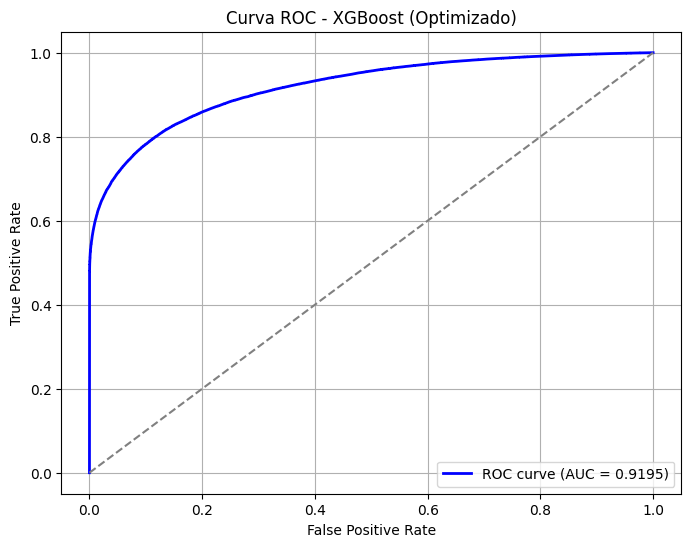

In [15]:
# Medir tiempo de entrenamiento
start_time = time.time()
xgb_optimized.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predicciones
y_pred = xgb_optimized.predict(X_test)
y_proba = xgb_optimized.predict_proba(X_test)[:, 1]  # Probabilidades para AUC-ROC

train_time = time.time() - start_time

# Evaluación
print("\n🔹 Modelo: XGBoost (Optimizado)")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Tiempo de entrenamiento: {train_time:.4f} segundos")

# Graficar la curva ROC para el modelo optimizado
plot_roc_curve(y_test, y_proba, "XGBoost (Optimizado)")


In [36]:
import lime
import lime.lime_tabular

# Crear explicador LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, 
    feature_names=X_train.columns.tolist(), 
    class_names=['Clase 0', 'Clase 1'], 
    mode="classification"
)

# Explicación para una instancia de prueba
i = 0  # Índice de la instancia a explicar
exp = explainer.explain_instance(X_test.iloc[i].values, xgb_optimized.predict_proba)

# Mostrar la explicación
exp.show_in_notebook()


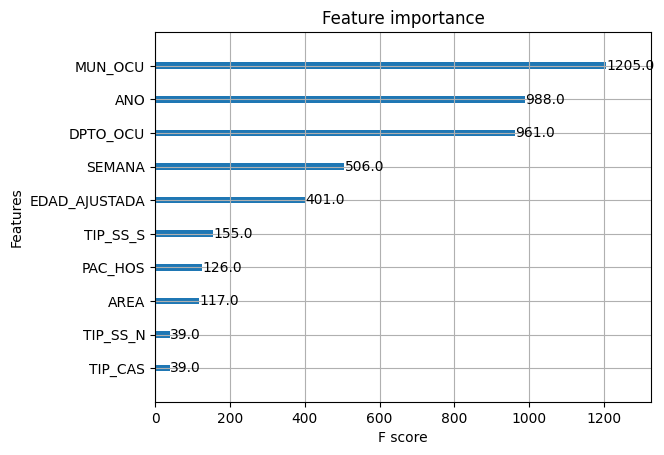

In [37]:
import xgboost as xgb

# Graficar importancia de características
xgb.plot_importance(xgb_optimized, importance_type="weight", max_num_features=10)
plt.show()


A pesar de que el tiempo de entrenamiento aumentó, el modolo logró **el mayor valor** de ROC AUC entre los algoritmos de clasificación evaluados. Además, los valores de las métricas se mantuvieron similares para ambas clases. La curva ROC obtenida presenta las mismas características que Random Forest. 

Para analizar la importancia de variables en la toma de decisiones del modelo, se empleó la librería  'LIME'. La siguiente figura muestra la contribución de las variables en la predicción de una observación específica: 

#### 📍 SVM

☑️ ParamGrid para la selección de los mejores parámetros

In [38]:
# SGD SVM con hiperparámetros optimizados
param_grid_sgd = {
    "alpha": [1e-4, 1e-3, 1e-2],
    "max_iter": [1000, 2000],
    "tol": [1e-3, 1e-4]
}

sgd_svm = GridSearchCV(SGDClassifier(loss="hinge", random_state=42), 
                       param_grid_sgd, cv=5, scoring="f1", n_jobs=-1, verbose=2)
sgd_svm.fit(X_train_scaled, y_train)

print("\n🔹 Mejor SGD SVM:")
print(sgd_svm.best_params_)
print(sgd_svm.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits

🔹 Mejor SGD SVM:
{'alpha': 0.0001, 'max_iter': 1000, 'tol': 0.0001}
0.7829284726606646


In [39]:
# Linear SVM con LinearSVC
linear_svm = LinearSVC(max_iter=5000, random_state=42)
linear_svm.fit(X_train_scaled, y_train)

# SVM con kernel RBF usando Random Fourier Features
rbf_feature = RBFSampler(gamma=1.0, random_state=42, n_components=500)  # Aproximación de kernel RBF
rbf_svm = Pipeline([
    ("rbf_feature", rbf_feature),
    ("svm", SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, random_state=42))
])
rbf_svm.fit(X_train_scaled, y_train)

Pipeline(steps=[('rbf_feature', RBFSampler(n_components=500, random_state=42)),
                ('svm', SGDClassifier(random_state=42))])

In [40]:
# Lista de Modelos optimizados
models_SVM= {
    "SGD SVM Optimizado": sgd_svm.best_estimator_,
    "Linear SVM": linear_svm,
    "SVM RBF (Random Fourier Features)": rbf_svm
}


🔹 Modelo: SGD SVM Optimizado
              precision    recall  f1-score   support

           0       0.69      0.78      0.73     80743
           1       0.82      0.74      0.78    108713

    accuracy                           0.76    189456
   macro avg       0.76      0.76      0.76    189456
weighted avg       0.77      0.76      0.76    189456

ROC-AUC: 0.8537
Tiempo de predicción: 0.0215 segundos


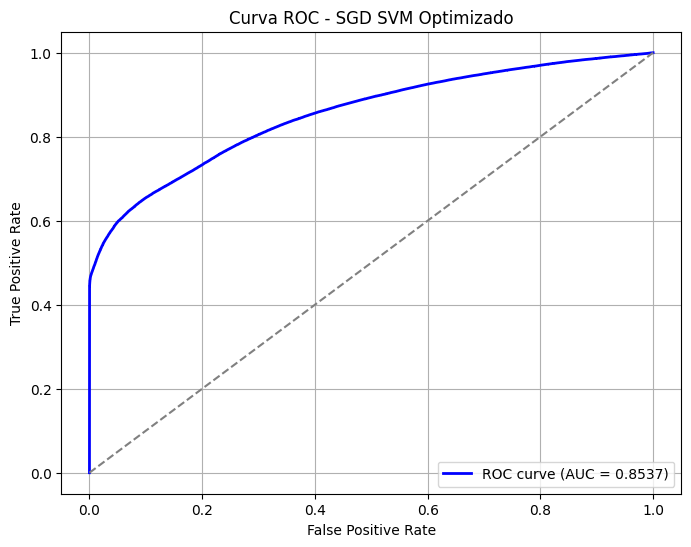


🔹 Modelo: Linear SVM
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     80743
           1       0.82      0.75      0.79    108713

    accuracy                           0.77    189456
   macro avg       0.76      0.77      0.76    189456
weighted avg       0.77      0.77      0.77    189456

ROC-AUC: 0.7680
Tiempo de predicción: 0.0105 segundos


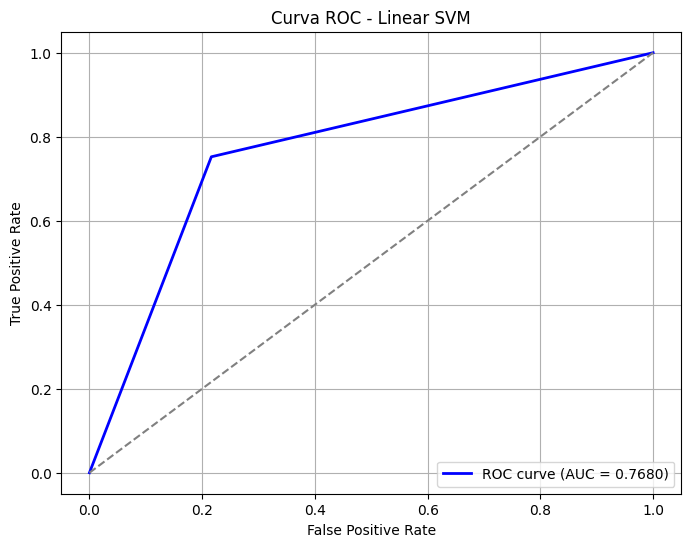


🔹 Modelo: SVM RBF (Random Fourier Features)
              precision    recall  f1-score   support

           0       0.64      0.58      0.61     80743
           1       0.71      0.75      0.73    108713

    accuracy                           0.68    189456
   macro avg       0.67      0.67      0.67    189456
weighted avg       0.68      0.68      0.68    189456

ROC-AUC: 0.6662
Tiempo de predicción: 1.5980 segundos


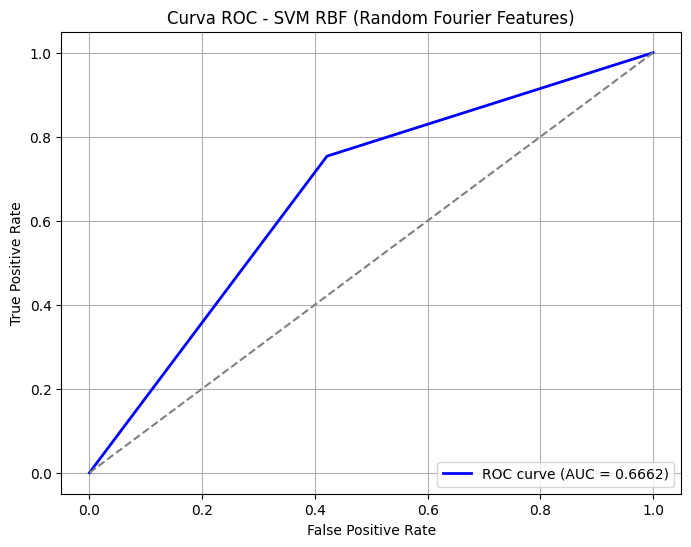

In [41]:
for name, model in models_SVM.items():
    print(f"\n🔹 Modelo: {name}")
    
    start_time = time.time()  # Iniciar temporizador
    y_pred = model.predict(X_val_scaled)  # Predicción
    end_time = time.time()  # Finalizar temporizador

    # Reporte de clasificación
    print(classification_report(y_val, y_pred))
    
    # Probabilidades calibradas (solo para SGD SVM)
    if name == "SGD SVM Optimizado":
        model = CalibratedClassifierCV(model, method='sigmoid', cv=5)
        model.fit(X_train_scaled, y_train)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        y_proba = y_pred  # No hay predict_proba en LinearSVC y SGDClassifier sin calibración

    # Métrica ROC-AUC
    roc_auc = roc_auc_score(y_val, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Tiempo de cómputo
    elapsed_time = end_time - start_time
    print(f"Tiempo de predicción: {elapsed_time:.4f} segundos")

    plot_roc_curve(y_val, y_proba, model_name=name)

    

Para **SVM** la optimización mejoró significativamente el tiempo de predicción, lo que hace a este modelo en términos computacionales. Sin embargo, en comparación con otros modelos evaluados el rendimiento general es inferior, reflejandose en un menor valor ROC-AUC. No obstante, el modelo identifica con mayor precision la Clase 1, aunque si capacidad de recall es más baja en comparación con otros clasificadores. La curva ROC también es una curva suave.  

Para **LinearSVC** la optimización del modelo refujo significativamente el tiempo de ntrenamiento a solo ($0,01$) segundos, lo que lo convierte en una opción eficiente. Sin embargo, el rendimiento en clasificación disminuyó, reflejado en una reducción del valor AUC. Esto indica que el modelo pasó de un desempeño bueno a moderado, posiblemente debido a la simplificación del hiperplano. La curva ROC, está segmentada en en dos partes, lo que indica un cambio en el rendimiento de las tasas después de cierto punto. 

Para **RBF Sampler** diferencia de LinearSVC, la incorporación de RBFSampler no mejoro el rendimiento del modelo, sino que lo empeoró. La precision y recall en la Clase 0 disminuyeron, el AUC bajo a $0.6662$, indicando una menor capacidad discriminatoria cercana al clasificador por defecto. El tiempo de entrenamiento aumentó, lo que indica mayor costo computacional sin beneficio significativo en la clasificación. implico una mejoría, de hecho, empeoró la capacidad de clasificación del modelo, disminuyendo la sensibilidad y precision para la Clase 0. La curva ROC, es cercana al clasificador por defecto, teniendo también un comportamiento por segmentos.

---

### **FASE 4**
Evaluación de los mejores modelos con el conjunto de test

In [21]:
# Lista de modelos a evaluar
models = {
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "RF Optimizado": rf_optimized,
}
X_test_scaled = scaler.transform(X_test)

☑️Resultados para XGBoost:
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     80743
           1       0.89      0.82      0.85    108713

    accuracy                           0.84    189456
   macro avg       0.83      0.84      0.84    189456
weighted avg       0.84      0.84      0.84    189456

AUC: 0.9195


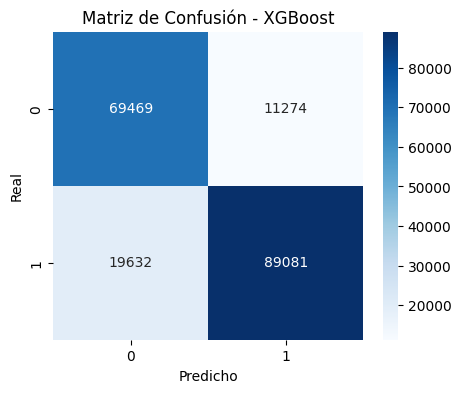

☑️Resultados para RF Optimizado:
              precision    recall  f1-score   support

           0       0.78      0.85      0.82     80743
           1       0.88      0.82      0.85    108713

    accuracy                           0.84    189456
   macro avg       0.83      0.84      0.84    189456
weighted avg       0.84      0.84      0.84    189456

AUC: 0.9186


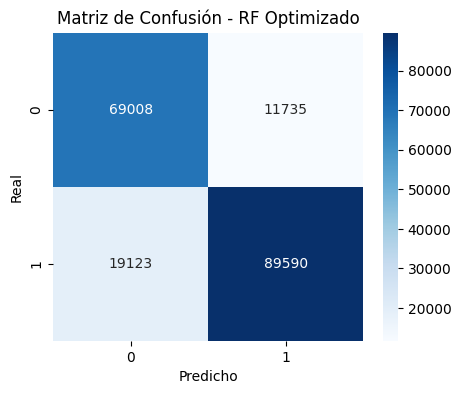

Resumen AUC en Test:
XGBoost: 0.9195
RF Optimizado: 0.9186


In [22]:
# Evaluación en test
results = {}
for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc
    
    print(f"☑️Resultados para {name}:")
    print(classification_report(y_test, y_pred))
    print(f"AUC: {auc:.4f}")

    # Matriz de confusión
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

# Comparar resultados
print("Resumen AUC en Test:")
for model, auc in results.items():
    print(f"{model}: {auc:.4f}")


Para **XGBoost** los valores de precision y recall, se mantienen balanceados, con una ligera ventaja en recall para la Clase 0 y en precision para la Clase 1. El valor de AUC, indica que el modelo logra un rendimiento sólido y consistente. La exactitud global del modelo es de $84\%$ lo que refuerza su capacidad predictiva. 

En cuanto a la matriz de confusión, el modelo en la mayoría de casos $(89.081)$ los clasifico correctamente como Clase 1. pacientes que realmente tenían Dengue. En general, tiene una buena capacidad de clasificación, con valores verdaderos positivos y verdadero negativos significativamente altos. El número de falsos negativos $(19.632)$ es mayor que el de falsos positivos $(11.274)$, lo que sugiere que el modelo tiende a ser más conservador en la clasificación de la Clase 1. En el contexto del estudio, un valor alto de falsos negativos (clasificación de pacientes infectados como no confirmados) es un valor a tener en cuenta, en lo que debe optimizarse la métrica de recall para la Clase 1. 

Para **Random Forest Optimizado** el rendimiento de este modelo es similar al de XGBoost, con una diferencia en el AUC($0.9195$). La matriz de confusión, también obtuvo un comportamiento similar, aumentando la cantidad de casos verdaderos positivos a $89.590$, disminuyendo los verdaderos negativos. La cantidad de falsos positivos aumento un poco, mientras que el numero de falsos negativos disminuyo para algunos casos.